# Weathering mediated bedrock erosion: Data

### Preliminaries

In [1]:
import wmbe, sympy as sy, numpy as np
# from matplotlib.pylab import plt
sy.init_printing(pretty_print=True,wrap_line=True)
from sympy import Eq
from wmbe.symbols import *

Here


## Rock weakness vs wetting/drying

In [2]:
ed = wmbe.data.ExptData()

In [3]:
ed.read_excel("inoue",
              dir_name=("..","data"), file_name="Inoue_wetdryN_sigmaT")
df = ed.ddict["inoue"]
df["w_sigma2"] = (df.sigmaT*2.21)**(-2)
df["w_sigma1p5"] = (df.sigmaT*2.21)**(-1.5)
ed.ddict["inoue"]

,wetdryN,sigmaT,w_sigma2,w_sigma1p5
0,0.0,0.450779,1.007601,1.005695
1,0.0,0.390966,1.339486,1.245098
2,0.0,0.240810,3.530746,2.575727
3,0.0,0.231464,3.821623,2.733291
4,0.0,0.210903,4.603076,3.142579
5,0.0,0.200312,5.102742,3.395101
6,1.0,0.190966,5.614416,3.647358
7,1.0,0.161059,7.893042,4.709050
8,1.0,0.131153,11.903134,6.408347
9,1.0,0.120561,14.086516,7.271143


In [4]:
ed.fit_linear_model("inoue","wetdryN","w_sigma2")

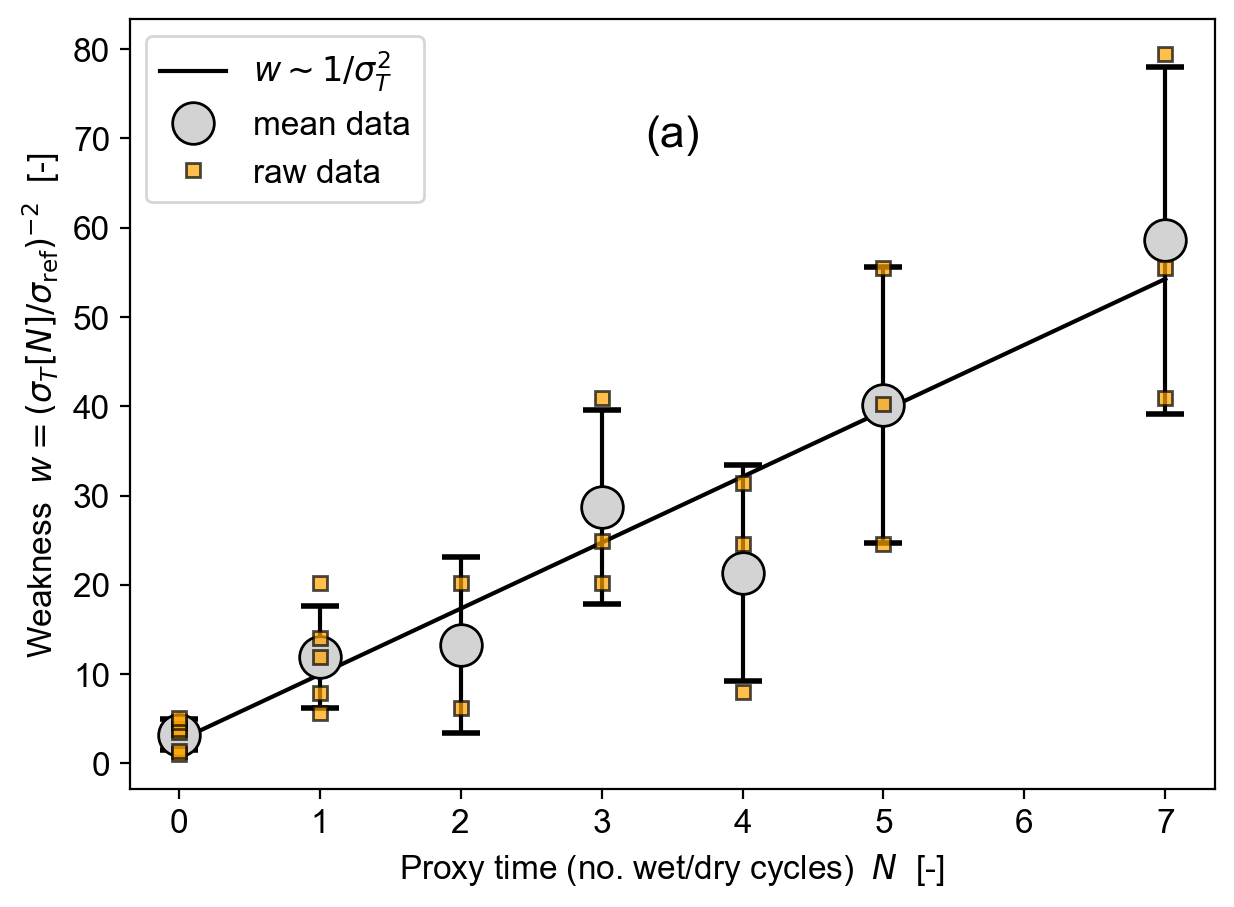

In [5]:
inoue_fig_w_wetdry = wmbe.plot.create_figure("inoue_w_wetdry")
wmbe.plot.plot_inoue_w_wetdryN(inoue_fig_w_wetdry,ed,  
                               text_label=((0.5,0.85),"(a)",16))

In [6]:
ed.read_excel("li",dir_name=("..","data"), file_name="Li_wetdryN_table1")
df = ed.ddict["li"]
sigma_sf = 180
# df["sigmaC_ref"] = np.tile((df.sigmaC[0:3]),6)
df["w_sigma2"]   = (df.sigmaC/180)**(-2)
df["w_sigma1p5"] = (df.sigmaC/180)**(-1.5)
ed.ddict["li"]

,wetdryN,P,sigmaC,Y,C,phi,w_sigma2,w_sigma1p5
0,0,2,110.02,26.71,13.86,56.29,2.676713,2.092673
1,0,6,174.54,24.78,13.86,56.29,1.063543,1.047288
2,0,10,185.97,30.97,13.86,56.29,0.936827,0.952236
3,1,2,96.81,18.38,12.75,54.66,3.457041,2.535295
4,1,6,147.38,8.99,12.75,54.66,1.491653,1.349743
5,1,10,173.21,28.06,12.75,54.66,1.079939,1.059374
6,5,2,95.50,23.79,13.44,52.57,3.552534,2.587639
7,5,6,133.66,24.94,13.44,52.57,1.813602,1.562811
8,5,10,165.11,28.95,13.44,52.57,1.188497,1.138279
9,15,2,71.39,9.11,7.89,56.24,6.357264,4.003618


In [7]:
ed.fit_linear_model("li","wetdryN","w_sigma2",select="P")

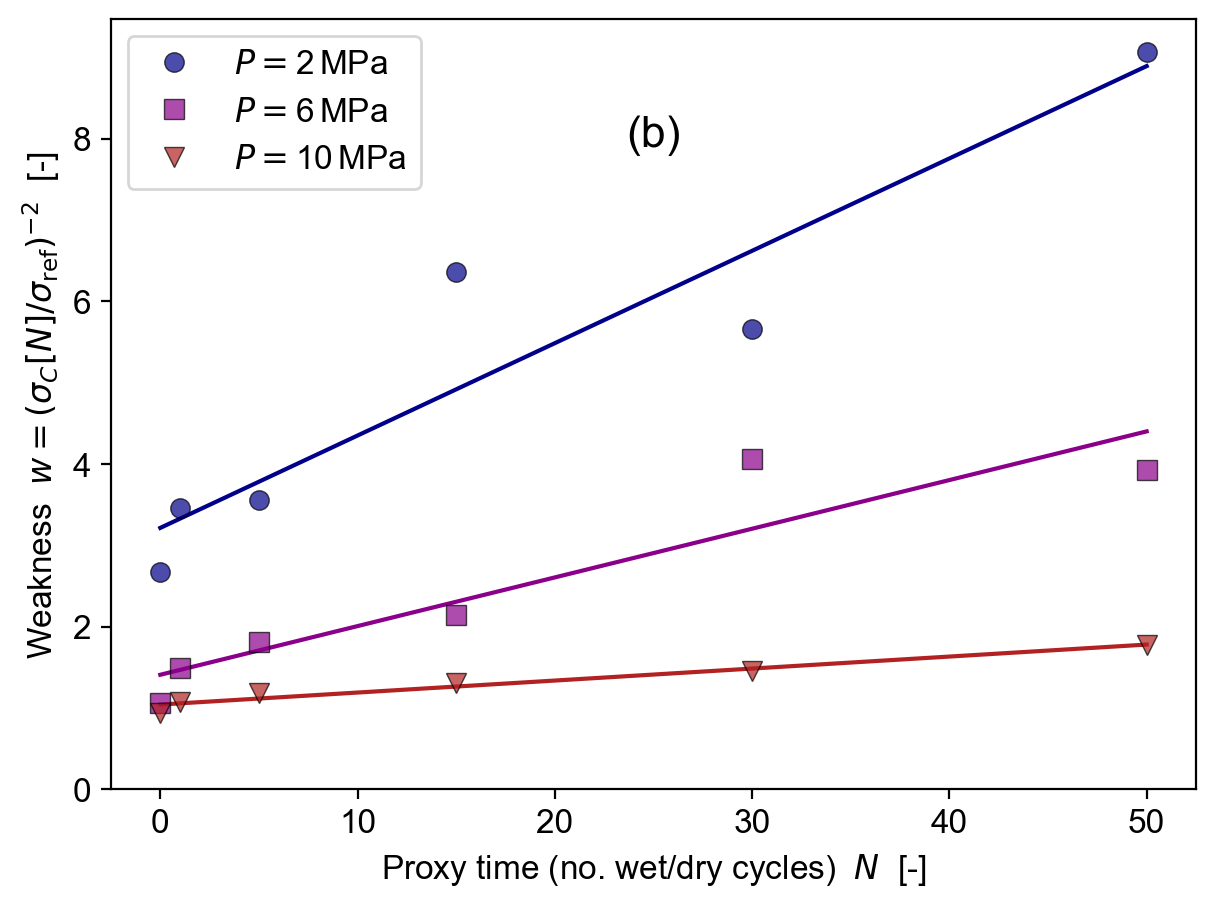

In [8]:
li_fig_w_wetdryN = wmbe.plot.create_figure("li_w_wetdryN")
wmbe.plot.plot_li_w_wetdryN(li_fig_w_wetdryN, ed,
                           text_label=((0.5,0.85),"(b)",16))

In [9]:
ed.fit_weathering_model("li","w_sigma2")

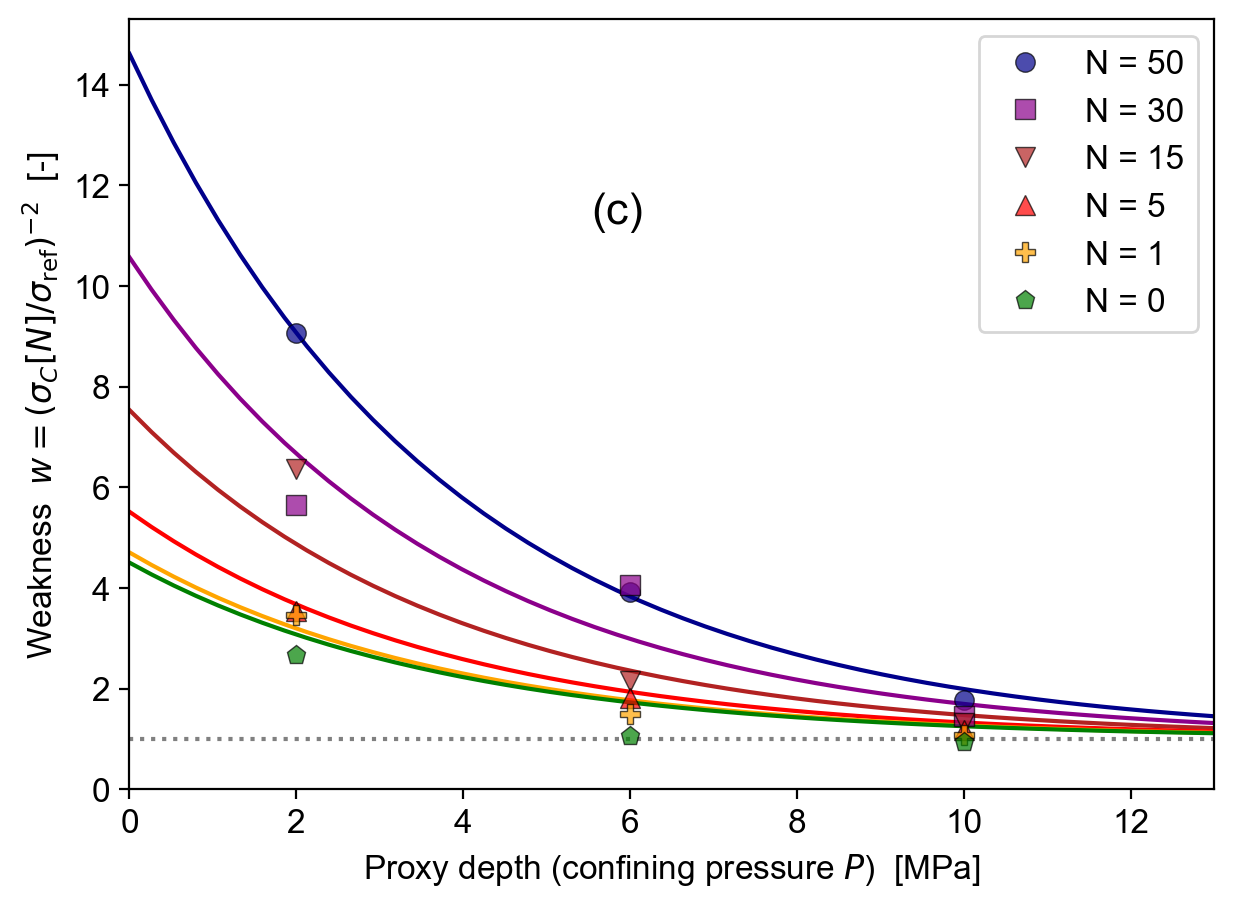

In [10]:
li_fig_w_P = wmbe.plot.create_figure("li_w_P")
wmbe.plot.plot_li_w_P(li_fig_w_P,ed, text_label=((0.45,0.75),"(c)",16))

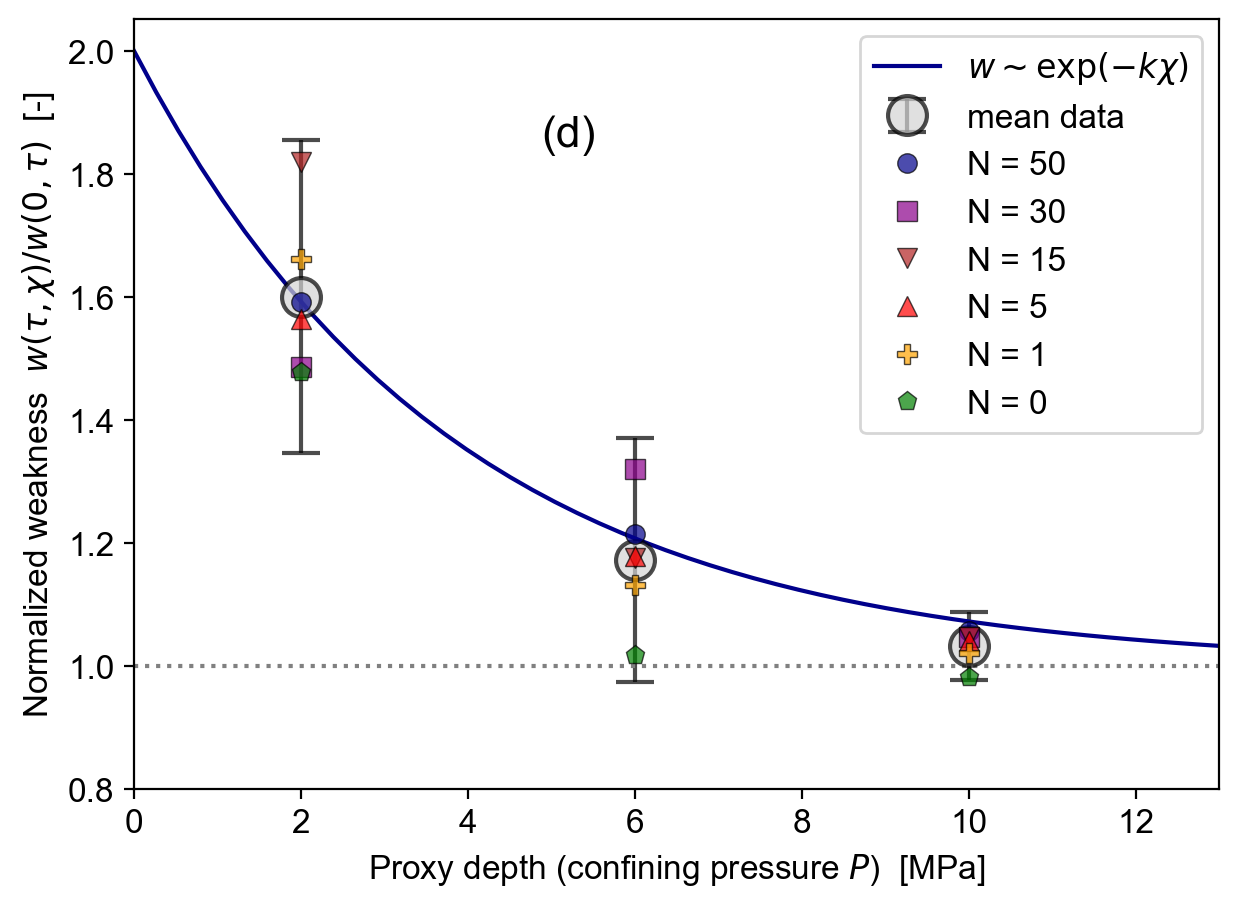

In [11]:
li_fig_w_normed_P = wmbe.plot.create_figure("li_w_normed_P")
wmbe.plot.plot_li_w_surface_normed_P(li_fig_w_normed_P,ed, 
                             text_label=((0.4,0.85),"(d)",16))

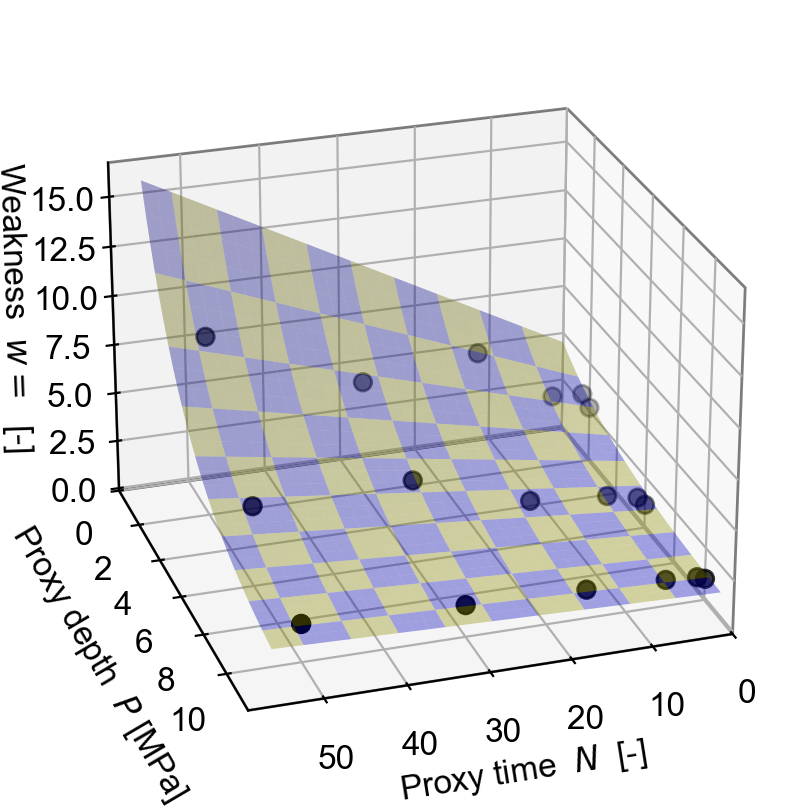

In [12]:
li_fig_w_wetdryN_P = wmbe.plot.create_figure("li_w_wetdryN_P")
wmbe.plot.plot_li_w_wetdryN_P(li_fig_w_wetdryN_P, ed,
                                  "li_w_sigma2_surface")

## Save

In [43]:
results_dir = wmbe.save.create_plots_dir()

In [44]:
wmbe.save.export_plots(wmbe.plot.fdict,results_dir,"pdf")

Exported "inoue_w_wetdry.pdf"
Exported "li_w_wetdryN.pdf"
Exported "li_w_P.pdf"
Exported "li_w_normed_P.pdf"
Exported "li_w_wetdryN_P.pdf"
Exported "highW_nu_evolution.pdf"
Exported "highW_eta_evolution.pdf"
Exported "highW_eta_evolution_subfigb.pdf"
Exported "highW_etas_ss.pdf"
Exported "highTransW_eta_evolution.pdf"
Exported "lowTransW_nu_evolution.pdf"
Exported "lowTransW_eta_evolution.pdf"
Exported "lowTransW_etas_ss.pdf"
Exported "lowW_nu_evolution.pdf"
Exported "lowW_eta_evolution_subfiga.pdf"
Exported "lowW_etas_ss.pdf"
Exported "etas_setW_ss.pdf"
Exported "nu_s.pdf"
Exported "nu_s_subfiga.pdf"
Exported "nu_s_approx_devn.pdf"
Exported "nu_s_approx_devn_subfigb.pdf"
Exported "z_w0_v0_vs_W_highW.pdf"
Exported "z_y_highW.pdf"
Exported "z_w0_v0_vs_W_transW.pdf"
Exported "z_y_transW.pdf"


In [45]:
fig = "highW_eta_evolution"
wmbe.save.export_plots({fig:wmbe.plot.fdict.get(fig)},results_dir,"png")
fig = "nu_s"
wmbe.save.export_plots({fig:wmbe.plot.fdict.get(fig)},results_dir,"png")

Exported "highW_eta_evolution.png"
Exported "nu_s.png"
